--- Iris PCA Results ---
Eigenvalues (Explained Variance): [2.93808505 0.9201649 ]
Explained Variance Ratio: [0.72962445 0.22850762]
Total Explained Variance: 0.9581


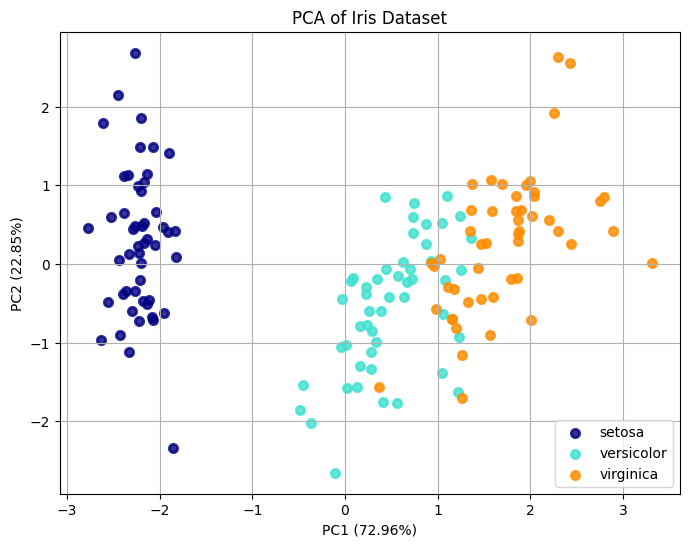

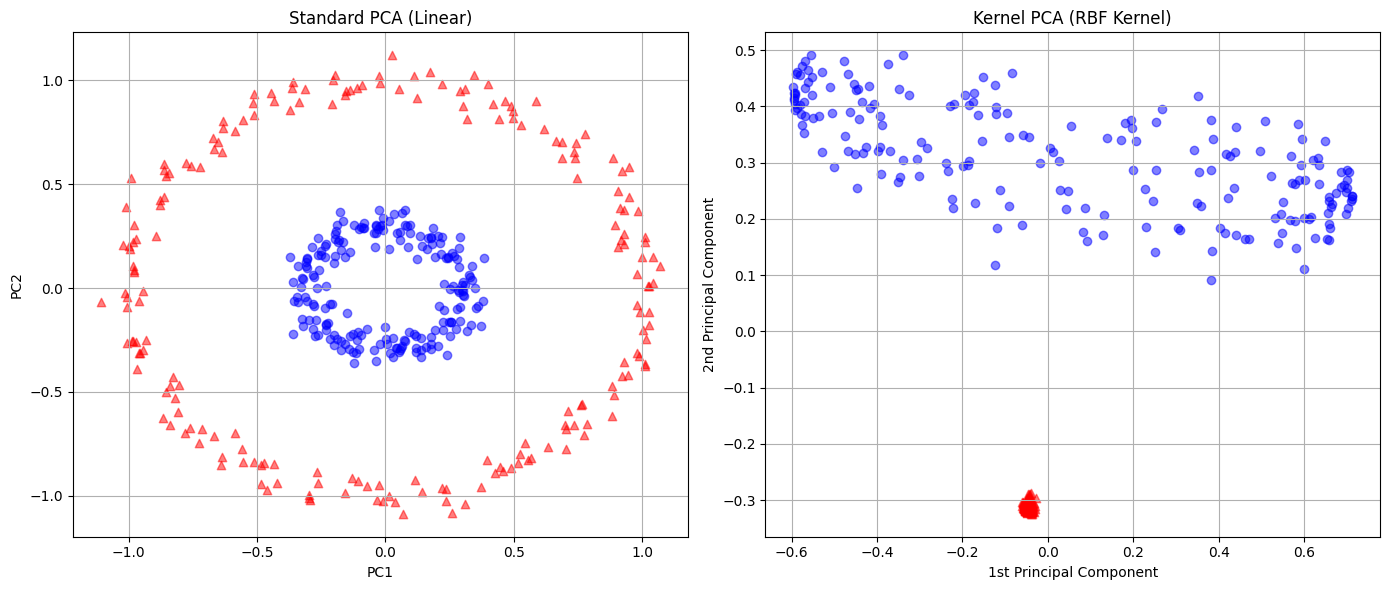

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA

# Part A: PCA on Iris Dataset
# 1. Load and Standardize
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

X_std = StandardScaler().fit_transform(X)

# 2. Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

# 3. Explained Variance
print("--- Iris PCA Results ---")
print(f"Eigenvalues (Explained Variance): {pca.explained_variance_}")
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Explained Variance: {sum(pca.explained_variance_ratio_):.4f}")

# 4. Visualize Iris PCA
plt.figure(figsize=(8, 6))
colors = ['navy', 'turquoise', 'darkorange']
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], color=color, alpha=.8, lw=lw,
                label=target_name)
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('PCA of Iris Dataset')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True)
plt.savefig('q7_iris_pca.png')
plt.show()

# Part B: PCA vs Kernel PCA on Circles
# 1. Generate Data
np.random.seed(0)
X_circles, y_circles = make_circles(n_samples=400, factor=.3, noise=.05)

# 2. Apply Standard PCA
pca_circles = PCA(n_components=2)
X_pca_c = pca_circles.fit_transform(X_circles)

# 3. Apply Kernel PCA (RBF)
kpca = KernelPCA(kernel="rbf", fit_inverse_transform=True, gamma=10)
X_kpca_c = kpca.fit_transform(X_circles)

# 4. Visualize Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot PCA
ax1.scatter(X_pca_c[y_circles == 0, 0], X_pca_c[y_circles == 0, 1], color='red', marker='^', alpha=0.5)
ax1.scatter(X_pca_c[y_circles == 1, 0], X_pca_c[y_circles == 1, 1], color='blue', marker='o', alpha=0.5)
ax1.set_title('Standard PCA (Linear)')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.grid(True)

# Plot Kernel PCA
ax2.scatter(X_kpca_c[y_circles == 0, 0], X_kpca_c[y_circles == 0, 1], color='red', marker='^', alpha=0.5)
ax2.scatter(X_kpca_c[y_circles == 1, 0], X_kpca_c[y_circles == 1, 1], color='blue', marker='o', alpha=0.5)
ax2.set_title('Kernel PCA (RBF Kernel)')
ax2.set_xlabel('1st Principal Component')
ax2.set_ylabel('2nd Principal Component')
ax2.grid(True)

plt.tight_layout()
plt.savefig('q7_circles_comparison.png')
plt.show()